<a href="https://colab.research.google.com/github/mostafaelhussien/hands-on-machine-learning/blob/main/Decision_Trees_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from matplotlib.legend_handler import HandlerLine2D

home_dir=Path(".").resolve()
main_dir=home_dir.parent
print(main_dir)
os.listdir()
from google.colab import drive
drive.mount("/content/drive")
os.listdir("/content/drive/MyDrive/ML Data")
data_dir="/content/drive/MyDrive/ML Data"
df=pd.read_csv(data_dir+'/healthcare-dataset-stroke-data.csv')
print(df.head())
print(df["stroke"].unique()) #[1,0]

#Rearrange
selected_columns = ['bmi', 'age', 'avg_glucose_level', 'heart_disease',
'ever_married', 'Residence_type', 'hypertension',
'smoking_status', 'gender', 'work_type', 'stroke', 'id']
df = df[selected_columns]
print(df.head())

#Checking and Handling Missing Values
print(df.isnull().sum())
percent_missing=df.isnull().sum()*100/len(df)
print(percent_missing)

#Drop any Column with more than 50% NaN

perc=50.0
min_count=int(((100-perc)/100)*df.shape[0]+1)
df=df.dropna(axis=1,thresh=min_count)
print(df.shape)

#Fill Remaining NA (Impute with Mean)
def fillna(df):
  numeric_columns=df.select_dtypes(include="number").columns
  df[numeric_columns]=df[numeric_columns].fillna(df[numeric_columns].mean().to_dict())
  categorical_columns=df.select_dtypes(exclude="number").columns
  df[categorical_columns]=df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])
  return df
df=fillna(df)
print(df.isnull().sum())

# Preparing Target Variable (Stroke)

print(df["stroke"].dtypes) #int64
unique_values=sorted(df["stroke"].unique())
print(unique_values)
df["stroke"]=np.where(df["stroke"]==unique_values[0],False,True)
print(df["stroke"].unique()) #(True,False)
print(df["stroke"].dtypes)
print(df['stroke'].value_counts())
print(df.describe())
print(df.head(5))

#Split

#1-Separate Features X from Target y
columns_to_drop_from_x=["stroke","id"]
X=df.drop(columns_to_drop_from_x,axis=1)
y=np.array(df["stroke"]) #scikit learn likes working with np.arrays

#2-Convert Text Columns(One hot Encoding using get dummies)
print(df.dtypes)
X=pd.get_dummies(X,columns=["hypertension","heart_disease","gender","ever_married","work_type","Residence_type","smoking_status"],dtype=float,drop_first=True)
#Hypertension and Heart Disease are Categorical not Continuous that's why they are included
#Drop First True is a kind of Feature Engineering
#print(X.dtypes)




/
Mounted at /content/drive
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
[1 0]
    bmi   age  avg_glu

DecisionTreeClassifier()


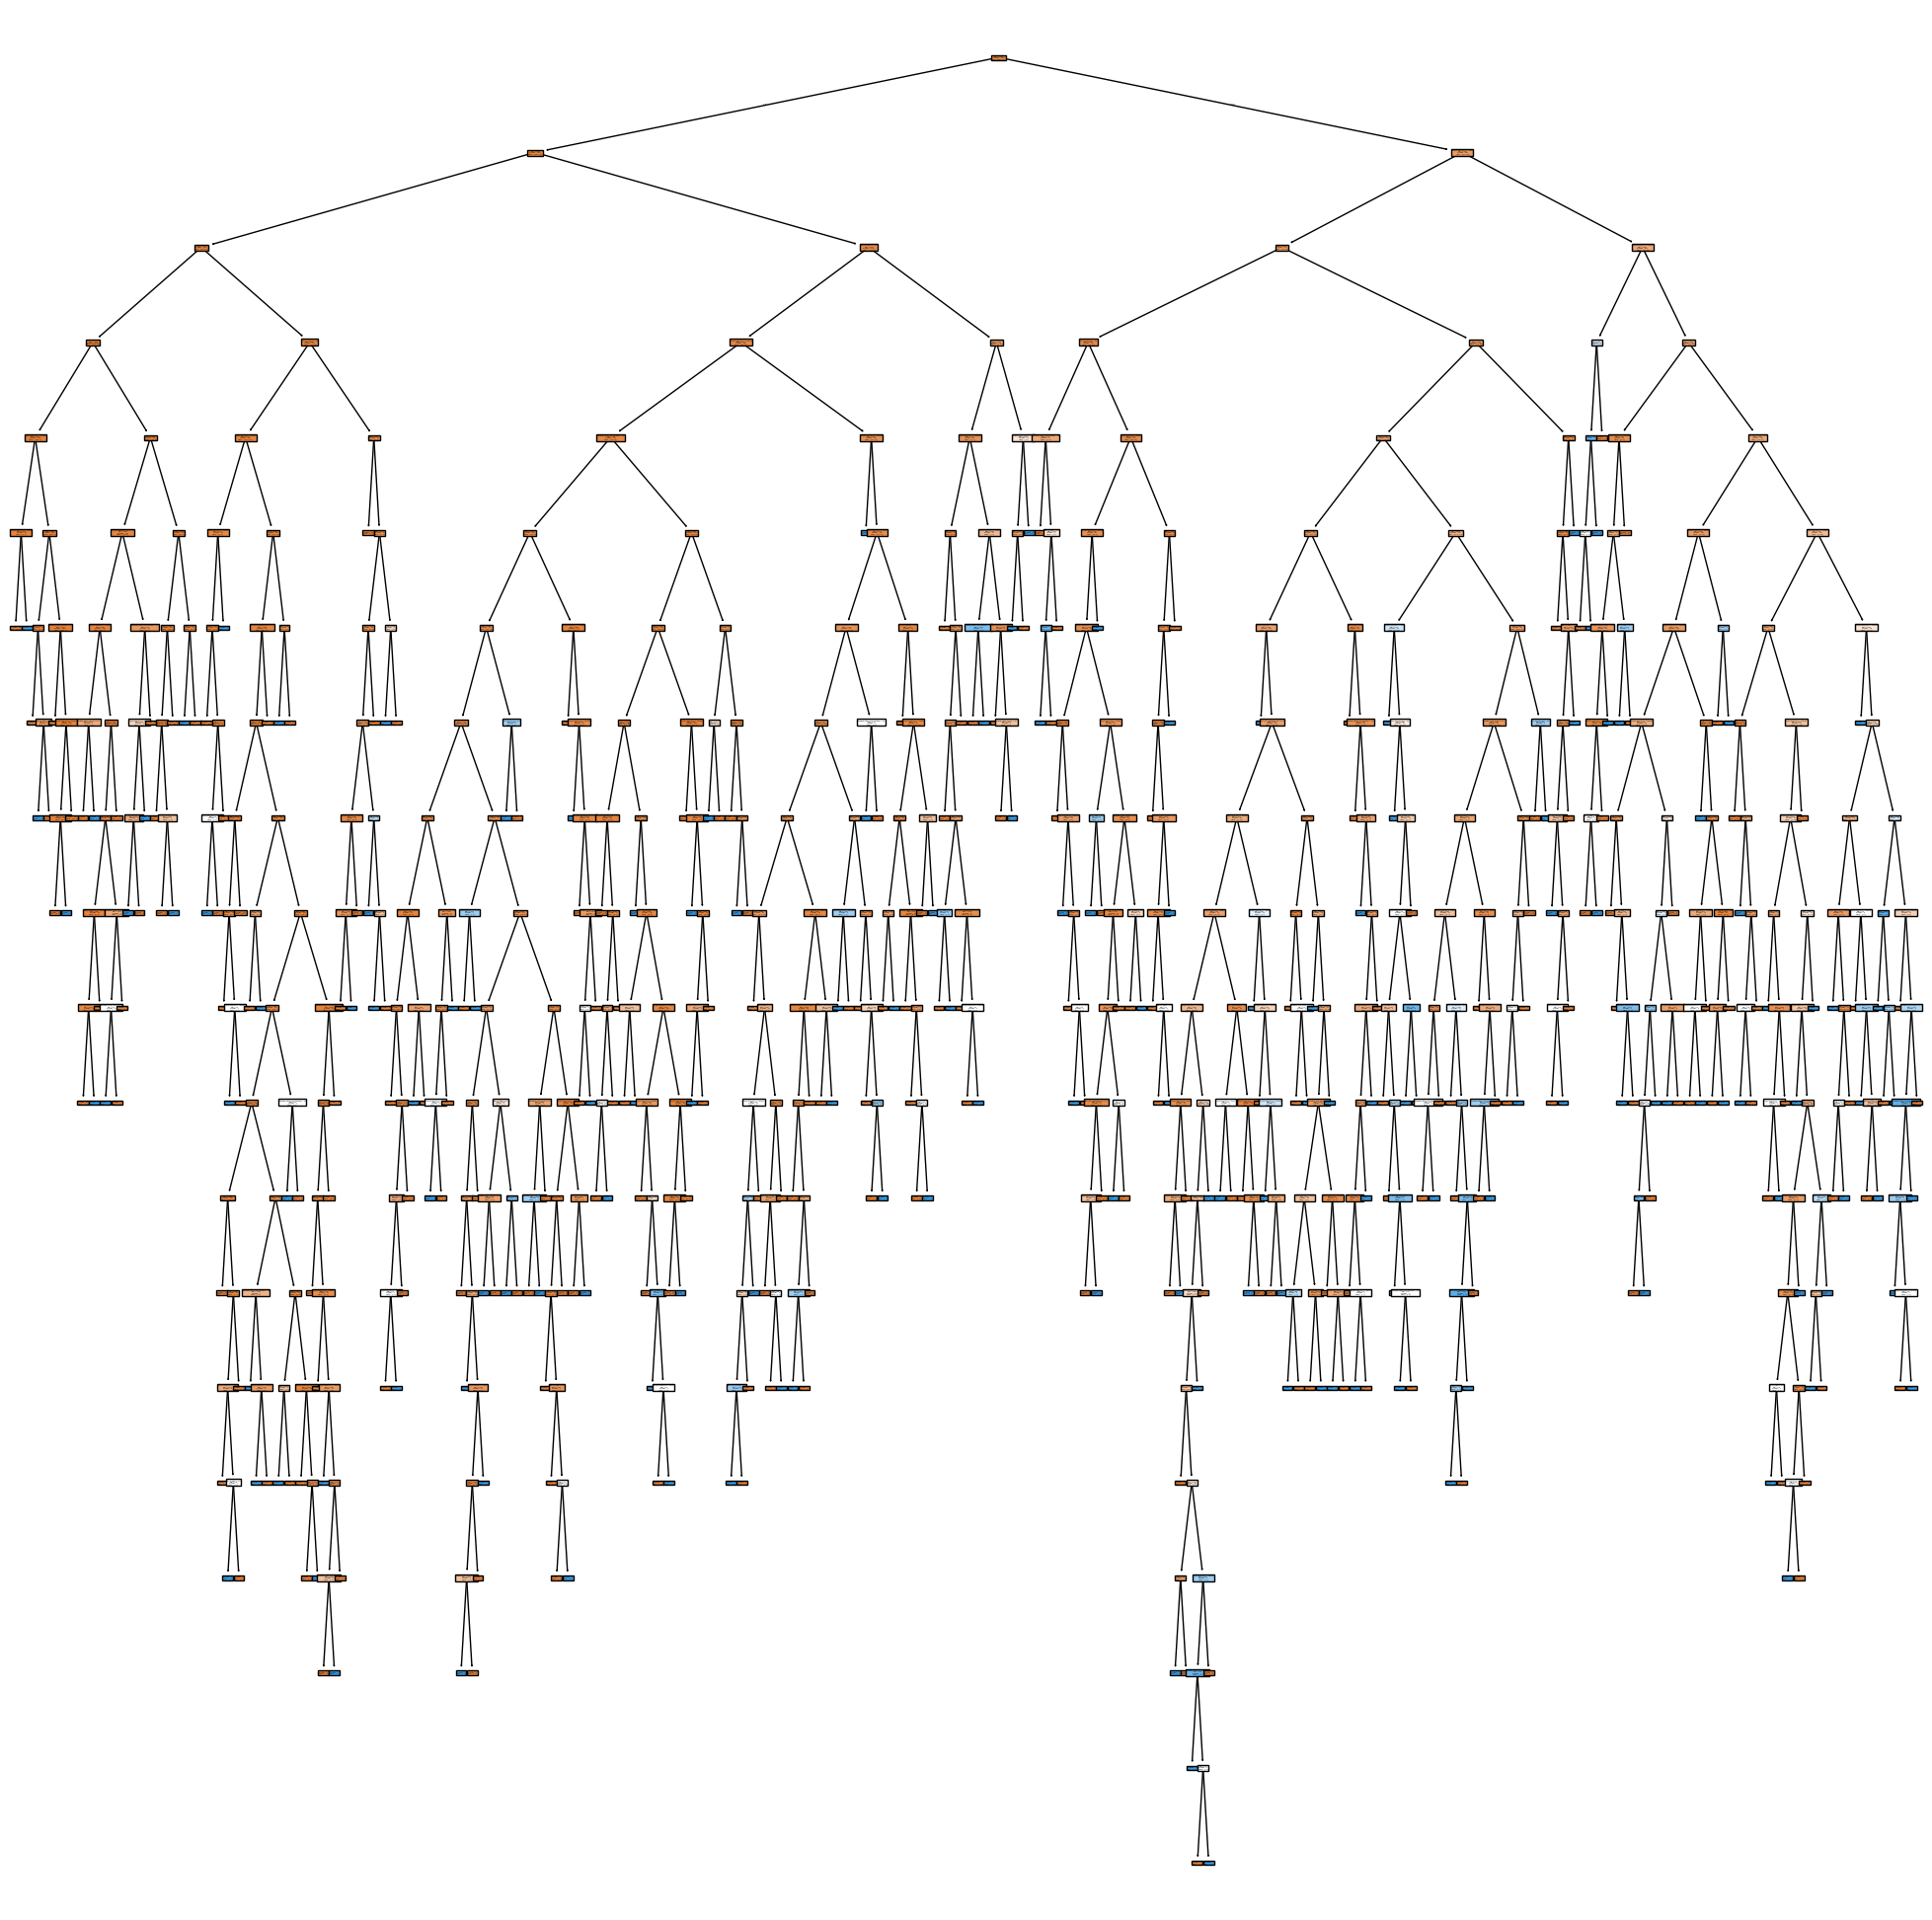

In [2]:
# Running Decision Tree Algorith for first time (examine)

dtc=tree.DecisionTreeClassifier()
dtc_fit=dtc.fit(X,y)
print(dtc_fit)

#Visualize Tree
fig=plt.figure(figsize=(25,25))
tree.plot_tree(dtc_fit,feature_names=X.columns,filled=True)
plt.show()

In [3]:
# Train Test Split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)
# dtc=tree.DecisionTreeClassifier()
# dtc_fit=dtc.fit(X_train,y_train)
# # Train ONLY on X_train/y_train. The test set is locked away — the model has NEVER seen it.
# y_predict=dtc_fit.predict(X_test)
# print(y_predict[:20])

(3577, 15) (3577,)
(1533, 15) (1533,)


In [4]:
# Learn (fit) on Training Data and predict labels for X_test Data

dtc=tree.DecisionTreeClassifier()
dtc_fit=dtc.fit(X_train,y_train)
# Train ONLY on X_train/y_train. The test set is locked away — the model has NEVER seen it.
y_predict=dtc_fit.predict(X_test)
print(y_predict[:20])

[False  True False  True False  True False False False False False False
 False False False False False False False False]


Decision Trees need numbers. But some columns have text like "Male"/"Female" or "Urban"/"Rural". get_dummies() converts them to 0s and 1s.

Example: gender column becomes gender_Male → 1 if Male, 0 if not.

drop_first=True: Avoids creating a redundant column. If we know it's not Male, it must be Female — so we only need one column, not two.

In [5]:
print(df.head(5))


         bmi   age  avg_glucose_level  heart_disease ever_married  \
0  36.600000  67.0             228.69              1          Yes   
1  28.893237  61.0             202.21              0          Yes   
2  32.500000  80.0             105.92              1          Yes   
3  34.400000  49.0             171.23              0          Yes   
4  24.000000  79.0             174.12              0          Yes   

  Residence_type  hypertension   smoking_status  gender      work_type  \
0          Urban             0  formerly smoked    Male        Private   
1          Rural             0     never smoked  Female  Self-employed   
2          Rural             0     never smoked    Male        Private   
3          Urban             0           smokes  Female        Private   
4          Rural             1     never smoked  Female  Self-employed   

   stroke     id  
0    True   9046  
1    True  51676  
2    True  31112  
3    True  60182  
4    True   1665  


In [6]:
# 3-Model Evaluation
# 3.A) Calculate Acc Score and Get Confusion Matrix for the First Model (before Tuning)
#Compares the real answers (y_test) with the model's guesses (y_predict),
#and counts how many fall into each of the four categories: TN, FP, FN, TP.

#Confusion  Matrix
cm_tree=confusion_matrix(y_test,y_predict)
print(cm_tree)
# [[1394 TN   64 FP]
#  [  58 FN   17 TP]]
#Accuracy Score
acc_score=accuracy_score(y_test,y_predict)
print(acc_score) #.9204

# #Visualize Confusion Matrix

# plt.clf()
#  #Clear figure — erases any previous plot so we start fresh.
#  #Good habit before plotting something new.
# plt.imshow(cm_tree,interpolation="nearest",cmap=plt.cm.Wistia)

# #  Draws the confusion matrix as a colored image.
# #  interpolation='nearest' makes the colors sharp (no blurring).
# #  cmap=plt.cm.Wistia is an orange-yellow color palette.
# classNames=["Negative","Positive"]
# plt.show()
# #The two categories we're predicting.
# # These are used to label the axes of the chart.
# plt.title("Confusion Matrix--Test Data")
# plt.ylabel("True label")
# plt.xlabel("Predicted label")
# tick_marks=np.arrange(len(classNames))

[[1385   78]
 [  62    8]]
0.908675799086758


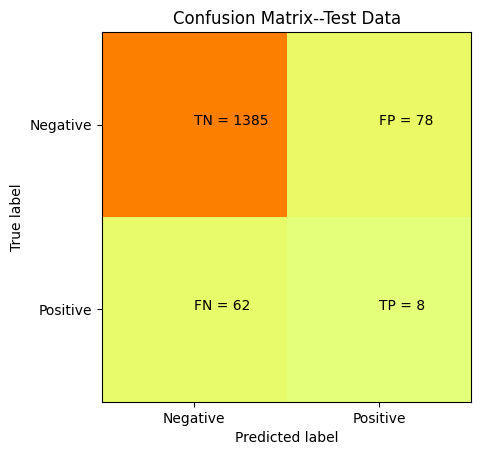

In [7]:
plt.clf()
 #Clear figure — erases any previous plot so we start fresh.
 #Good habit before plotting something new.
plt.imshow(cm_tree,interpolation="nearest",cmap=plt.cm.Wistia)

#  Draws the confusion matrix as a colored image.
#  interpolation='nearest' makes the colors sharp (no blurring).
#  cmap=plt.cm.Wistia is an orange-yellow color palette.
classNames=["Negative","Positive"]
#The two categories we're predicting.
# These are used to label the axes of the chart.
plt.title("Confusion Matrix--Test Data")
plt.ylabel("True label")
plt.xlabel("Predicted label")
tick_marks=np.arange(len(classNames))
plt.xticks(tick_marks,classNames)
plt.yticks(tick_marks,classNames)
s=[["TN","FP"],["FN","TP"]]
for i in range(2):
  for j in range(2):
    plt.text(j,i,str(s[i][j])+" = "+str(cm_tree[i][j]))
plt.show()

0.5304853041695147


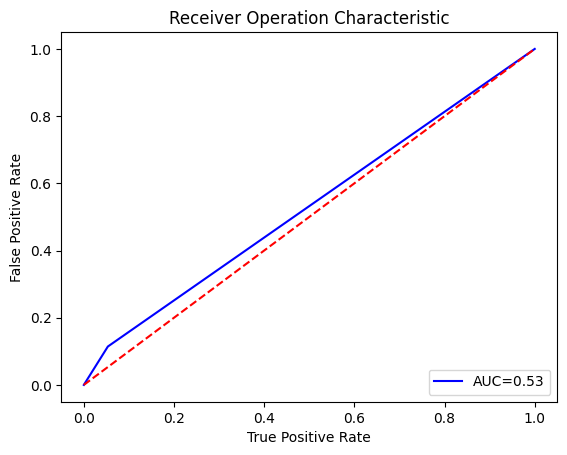

In [8]:
#3.B ROC Curve and AUC

#Calculate ROC Metrics and AUC

fpr,tpr,threshold=metrics.roc_curve(y_test,y_predict)
roc_auc=metrics.auc(fpr,tpr)
print(roc_auc) #.5753

#plot ROC Curve

plt.plot(fpr,tpr,"blue",label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],"r--")
plt.legend(loc="lower right")
plt.title("Receiver Operation Characteristic")
plt.xlabel("True Positive Rate")
plt.ylabel("False Positive Rate")
plt.show()


In [9]:
#4-Building Decision Tree on Full Dataset

#A.Build

clf=tree.DecisionTreeClassifier()
print(clf)

#B-Fit(Train)(learn)

clf_fit=clf.fit(X_train,y_train)

#C-Predict--Predict LAbels for X_test Data
y_predict=clf_fit.predict(X_test)
print(y_predict[:20])

#D-Test Accuracy
tree_accuracy_score=metrics.accuracy_score(y_test,y_predict)
print(tree_accuracy_score) #.913

#E-Training Accuracy
tree_training_accuracy=clf_fit.score(X_train, y_train)
print(tree_training_accuracy) #1--Definetely OVerfitting

#F-Save Results.

model_final_tree={
    "metrics" : "Accuracy",
    "values"  :round(tree_accuracy_score,4),
    "model" : "Decision Tree"
}
print(model_final_tree)

DecisionTreeClassifier()
[False  True False  True False  True False False False  True False False
 False False False False False False False False]
0.9165035877364645
1.0
{'metrics': 'Accuracy', 'values': 0.9165, 'model': 'Decision Tree'}


In [10]:
#D-Test Accuracy
tree_accuracy_score=metrics.accuracy_score(y_test,y_predict)
print(tree_accuracy_score)

0.9165035877364645


In [11]:
#5.Cross Validation

clf=tree.DecisionTreeClassifier()
cv_scores=cross_val_score(clf,X,y,cv=10)
print(cv_scores)
#[0.90802348 0.92759295 0.90410959 0.90410959 0.89823875 0.89236791
# 0.90606654 0.91976517 0.91193738 0.91780822]

mean=np.mean(cv_scores)
print(mean.round(4)) #.9125
print(f"CV Scores Mean: {mean.round(4)}") #9125


[0.91389432 0.91389432 0.8962818  0.91780822 0.90215264 0.8962818
 0.91193738 0.91389432 0.90802348 0.92563601]
0.91
CV Scores Mean: 0.91


In [12]:
#1-The optimal_parameter helper function:

def optimal_parameter(values,test_results):
  best_test_value=max(test_results)
  #Finds the highest accuracy score from all the values we tested.
  # This is the best performance we measured.
  best_test_index=test_results.index(best_test_value)
  #Finds which position in the list that best score is at.
  # E.g., if the 3rd value we tested was best, this returns index 2.
  best_value=values[best_test_index]
  #Uses that index to look up the parameter value that produced the best score.
  #This is what we'll pass into our final optimized model.

  return(best_value)






In [13]:
#1-Optimizing max Depth
# max_depth = how many times the tree is allowed to ask a question and split.
# Deeper tree = more complex rules = potentially smarter
# but also more prone to memorizing the training data (overfitting).

max_depths=range (1,33) #We test depths 1, 2, 3, … all the way up to 32.
#This gives us 32 different models to compare.
train_results=[]
test_results=[]
#Empty lists that will grow inside the loop —
#each iteration adds one accuracy score for training and one for testing.
for max_depth in max_depths:
  #Loop that runs 32 times. Each time, max_depth gets the next value (1, then 2, then 3, …).
  dt=DecisionTreeClassifier(max_depth=max_depth)
  #Creates a new tree each loop iteration with that specific depth.
  #We don't reuse the same model — we build a fresh one every time.
  dt.fit(X_train,y_train)
  train_pred=dt.predict(X_train)
  acc_train=accuracy_score(y_train,train_pred)
  train_results.append(acc_train)

# dt.predict(X_train) = الموديل بيتنبأ لنفس بيانات التدريب (اللي اتعلم عليها)
# accuracy_score(...) = يحسب نسبة الصح من التوقعات مقارنة بالـ labels الحقيق (y_train)
# نخزن النتيجة في train_results

# ✅ الهدف من تدريب accuracy: تشوف هل الموديل “بيتعلم” ولا لا، وهل بيتجه للحفظ

  y_pred=dt.predict(X_test)
  acc_test=accuracy_score(y_test,y_pred)
  test_results.append(acc_test)

# dt.predict(X_test) = التوقع على بيانات ماشفهاش أثناء التدريب
# نحسب accuracy ونخزنها في test_results

# ✅ الهدف من test accuracy: دي الأهم لأنها بتقيس التعميم (generalization)
optimal_max_depth=optimal_parameter(max_depths,test_results)

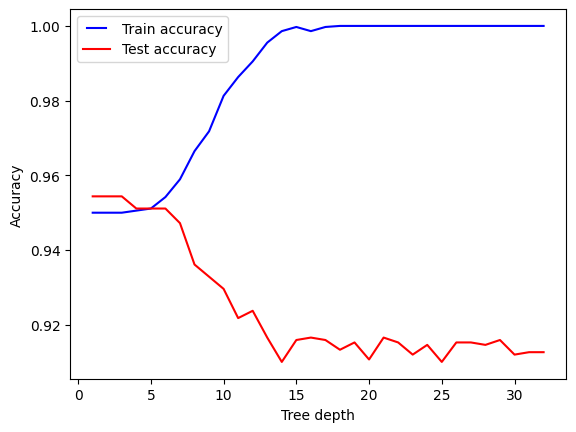

In [14]:
# Plot max depth over 1 - 32.
line1, = plt.plot(max_depths, train_results, 'b', label= "Train accuracy")
line2, = plt.plot(max_depths, test_results, 'r', label= "Test accuracy")

plt.legend(handler_map={line1: HandlerLine2D(numpoints = 2)})
plt.ylabel('Accuracy')
plt.xlabel('Tree depth')
plt.show()

In [15]:
#2-Optimizing min_samples_split

# min_samples_split = the minimum number of data points a node must contain
#  before the tree is allowed to split it further.
#   A higher value means the tree is more conservative
# — it won't split unless there's enough data to justify it.
# ❖ Analogy
# Imagine a school dividing students into groups.
#  If you set the rule "don't create a subgroup unless there are at least 20 students,"
#   small groups stay merged. This prevents creating overly specific rules based on tiny samples.

min_samples_splits=np.linspace(0.1,1.0,10,endpoint=True)
#Creates 10 evenly spaced values from 0.1 to 1.0: [0.1, 0.2, 0.3, …, 1.0]
train_results=[]
test_results=[]
for min_samples_split in min_samples_splits:
    dt=DecisionTreeClassifier(min_samples_split=min_samples_split)
    dt.fit(X_train,y_train)
    train_pred=dt.predict(X_train)
    acc_train=accuracy_score(y_train,train_pred)
    train_results.append(acc_train)
    y_pred=dt.predict(X_test)
    acc_test=accuracy_score(y_test,y_pred)
    test_results.append(acc_test)

optimal_min_samples_split=optimal_parameter(min_samples_splits,test_results)

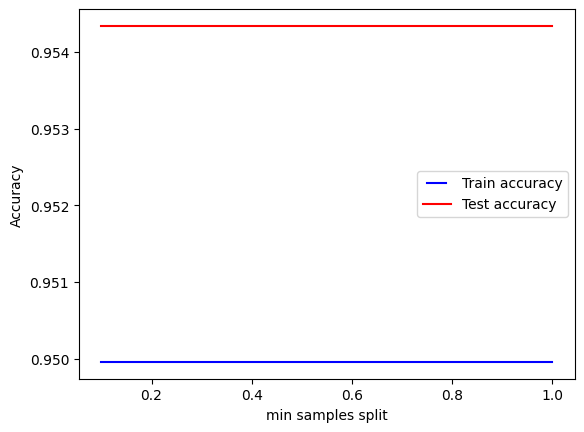

In [16]:
#Plot min_samples_split

line1, = plt.plot(min_samples_splits, train_results, 'b', label= "Train accuracy")
line2, = plt.plot(min_samples_splits, test_results, 'r', label= "Test accuracy")
plt.legend(handler_map={line1: HandlerLine2D(numpoints = 2)})
plt.ylabel('Accuracy')
plt.xlabel('min samples split')
plt.show()

In [17]:
# Optimizing min Sample Leaf

#min_samples_leaf is similar to min_samples_split but applies to the end nodes (leaves) of the tree.
#  A leaf must have at least this many samples.
#   This prevents the tree from
#   creating tiny leaf nodes that represent only 1–2 edge cases.

min_samples_leafs=np.linspace(0.1,0.5,5,endpoint=True)
train_results=[]
test_results=[]
for min_samples_leaf in min_samples_leafs:
    dt=DecisionTreeClassifier(min_samples_split=min_samples_split)
    dt.fit(X_train,y_train)
    train_pred=dt.predict(X_train)
    acc_train=accuracy_score(y_train,train_pred)
    train_results.append(acc_train)
    y_pred=dt.predict(X_test)
    acc_test=accuracy_score(y_test,y_pred)
    test_results.append(acc_test)
optimal_min_samples_leaf=optimal_parameter(min_samples_leafs,test_results)

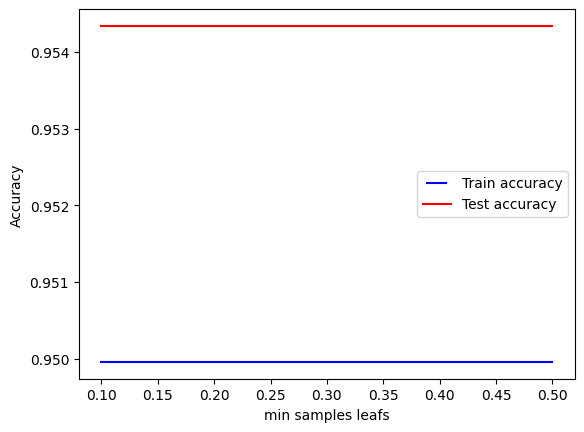

In [18]:
# Plot min_sample_leaf

line1, = plt.plot(min_samples_leafs, train_results, 'b', label= "Train accuracy")
line2, = plt.plot(min_samples_leafs, test_results, 'r', label= "Test accuracy")
plt.legend(handler_map={line1: HandlerLine2D(numpoints = 2)})
plt.ylabel('Accuracy')
plt.xlabel('min samples leafs')
plt.show()

In [19]:
# Max_features:
max_features = list(range(1,X.shape[1]))
train_results = []
test_results = []

for max_feature in max_features:
   dt = DecisionTreeClassifier(max_features=max_feature)
   dt.fit(X_train, y_train)
   train_pred = dt.predict(X_train)
   acc_train = accuracy_score(y_train, train_pred)
   # Add accuracy score to previous train results
   train_results.append(acc_train)
   y_pred = dt.predict(X_test)
   acc_test = accuracy_score(y_test, y_pred)
   # Add accuracy score to previous test results
   test_results.append(acc_test);

optimal_max_features = optimal_parameter(max_features,test_results)

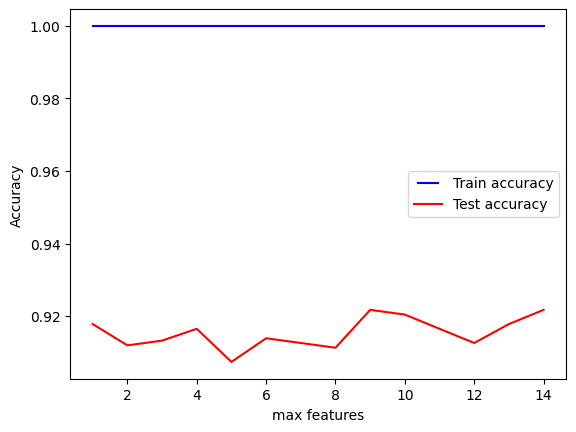

In [20]:
#Plot Max Features

line1, = plt.plot(max_features, train_results, 'b', label= "Train accuracy")
line2, = plt.plot(max_features, test_results, 'r', label= "Test accuracy")
plt.legend(handler_map={line1: HandlerLine2D(numpoints = 2)})
plt.ylabel('Accuracy')
plt.xlabel('max features')
plt.show()

In [21]:
# Optimizing Max Features

# max_features = how many features (columns) the tree is allowed to consider at each split point.
#  By default (None), it looks at all of them.
#   Limiting this adds randomness and can sometimes reduce overfitting.

# max_features=list(range(1,X.shape[1]))
# train_results = []
# test_results  = []
# # X.shape[1] دي معناها إيه؟

# # X.shape بيرجع أبعاد الداتا: (عدد_الصفوف, عدد_الأعمدة)
# # X.shape[1] = عدد الأعمدة (features) في X

# # مثلاً لو X_train.shape = (3577, 15) يبقى:

# # X.shape[1] = 15  ← عندك 15 feature


# # 2) range(1, X.shape[1]) بتطلع إيه؟
# # range(1, 15) مثلاً بتطلع أرقام من 1 لحد 14 (لأن النهاية غير شاملة):

# # 1, 2, 3, ..., 14

# # يعني بتستبعد 15.
# # list(...) ليه؟
# # لأن range وحدها بتبقى “مولّد” (iterable)
# # وإحنا عايزينها قائمة فعلية نقدر نلف عليها أو نطبعها:

# # تتحول لـ: [1, 2, 3, ..., 14]

# for max_feature in max_features:
#     dt=DecisionTreeClassifier(max_features=max_feature)
#     dt.fit(X_train,y_train)
#     train_pred=dt.predict(X_train)
#     acc_train=accuracy_score(y_train,train_pred)
#     train_results.append(acc_train)
#     y_pred=dt.predict(X_test)
#     acc_test=accuracy_score(y_test,y_pred)
#     test_results.append(acc_test)
# optimal_max_features=optimal_parameter(max_features,test_results)

In [22]:

print(optimal_max_depth) #1
print(optimal_min_samples_split)
print(optimal_min_samples_leaf)
print(optimal_max_features)
np.random.seed(1)
clf_optimized_params={
    "max_depth":optimal_max_depth,
    "min_samples_split":optimal_min_samples_split,
    "min_samples_leaf":optimal_min_samples_leaf,
    "max_features":optimal_max_features,
}
print(clf_optimized_params)

# Create a DecisionTreeClassifier instance with the optimized parameters
clf_optimized_model = tree.DecisionTreeClassifier(**clf_optimized_params)

# Fit the model
clf_optimized_fit = clf_optimized_model.fit(X_train,y_train)
y_predict_optimized=clf_optimized_fit.predict(X_test)
acc_score_optimized=accuracy_score(y_test,y_predict_optimized)
print(acc_score_optimized)
acc_train_optimized=clf_optimized_fit.score(X_train,y_train)
print(acc_train_optimized)

model_final_tree={
    "metrics" : "Accuracy",
    "values"  :round(acc_score_optimized,4),
    "model" : "Decision Tree"
}
print(model_final_tree)


1
0.1
0.1
9
{'max_depth': 1, 'min_samples_split': np.float64(0.1), 'min_samples_leaf': np.float64(0.1), 'max_features': 9}
0.954337899543379
0.949958065417948
{'metrics': 'Accuracy', 'values': 0.9543, 'model': 'Decision Tree'}


In [23]:

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_predict_optimized))
print(classification_report(y_test, y_predict_optimized))

[[1463    0]
 [  70    0]]
              precision    recall  f1-score   support

       False       0.95      1.00      0.98      1463
        True       0.00      0.00      0.00        70

    accuracy                           0.95      1533
   macro avg       0.48      0.50      0.49      1533
weighted avg       0.91      0.95      0.93      1533



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# ***Decision Trees:***

Three Vocabularies:

1-🌱 Root Node

The very first question the tree asks. It is the most important question — the one that gives the most useful information to split the data.

2-🌿 Decision Nodes (Branches)

Questions asked after the root node. Each answer leads to another question or to a final answer. Lines connecting questions are called branches.

3-
🍃 Leaf Nodes (Terminal)

The final answers at the bottom of the tree. No more questions — just the result: Stroke / No Stroke, Yes / No, etc.

---------------------------------------------------------------

✅ Why Use Decision Trees? Pros & Cons

 Pros (Good things)

Easy to explain to non-technical people

Works with numbers AND text (categories)

Handles missing data pretty well

No need to scale/normalize data

Works when data has weird non-linear patterns

Cons (Bad things)

1-Overfitting — memorises training data too well, fails on new data

Imagine a student who memorises every answer from the practice exam. When the real exam has slightly different questions, they fail. That's overfitting. The tree learned the training data "too well" and can't generalise.



2-Unstable — small change in data = completely different tree

3-Biased if one class appears much more than another

--------------------------------------------------------------

🔄 The 4-Step Decision Tree Process

Step 1 — Grow: Feed training data to the algorithm. It builds the tree by finding the best questions to ask.

Step 2 — Examine: Look at the tree. Is it too big? Too complex? Did it overfit?

Step 3 — Prune: "Pruning" means cutting branches that don't help. Like trimming a real tree! This prevents overfitting.

Step 4 — Check: Use the confusion matrix and accuracy score on the test data to see how good the model is.

---------------------------------------------------------------

🌱 Growing a Tree — The 4 Steps Inside the Algorithm

Step 1

Find Root Node

Ask the question with the most information. E.g. "Are you married?" tells us more than "What music do you like?" when predicting a 2nd date.

Step 2

Find Decision Nodes

Given the first answer, find the next most useful question below the root node.

Step 3

Identify Leaf Nodes

Stop branching when answers give no more new information. Those become leaf (terminal) nodes.

Step 4

Repeat

Repeat Steps 2 and 3 for every branch of the tree until done.

-----------------------------------------------------------------------------

🔢 The Math: Gini Impurity — How the Tree Decides Which Question to Ask First

What is Gini?

The tree uses Gini Impurity to measure how "mixed up" a group is. Lower Gini = purer group = better split.

Think of it like this: if a bag has only green balls → Gini = 0 (perfectly pure). If it has equal green and red balls → Gini = 0.5 (maximum mess).

scikit-learn uses Gini by default. There is another option called "Entropy" (information gain), but Gini is the default and what this course focuses on. Both measure impurity — just with slightly different formulas.

Gini(E) = 1 − Σ (Pⱼ)²

Pⱼ = probability (fraction) of samples belonging to class j

3 green, 3 red (equally mixed)

	1 − (3/6)² − (3/6)² = 1 − 0.25 − 0.25	=0.50
  
  	Very impure — tree can't decide well

4 green, 2 red (leaning green)

1 − (4/6)² − (2/6)² = 1 − 0.44 − 0.11=.44

A bit better — leaning towards one class

6 green, 0 red (all same class)

1-(6/6)²-(0/6)²=1-1=0

Perfectly Pure Node,easy to Classify




After Preprocessing (Step 2),we start with Model Evaluation (Step 3)

Our Tools for Evaluation are:

1-Accuracy Score

% of correct predictions


2-Confusion Matrix

TN,FP,FN,TP,Recall,Precision,FPR,TPR

Imagine you built a spam filter for your email. Accuracy tells you "it got 90% right." But the confusion matrix tells you something more specific — how many real emails did it accidentally delete (False Positives)? And how many spam emails did it miss (False Negatives)? Both matter, and they matter differently depending on the situation.



3-ROC Curve

Plot FPR against TPR

4-Area Under Curve AUC

Number between 0-1

AUC (Area Under the Curve) is a single number that measures how well a model distinguishes between positive and negative classes, representing the area under the ROC curve; it equals the probability that the model ranks a random positive sample higher than a random negative sample.

An AUC ≥ 0.8 is generally considered good,

 and ≥ 0.9 is excellent.

 --------------------------------------------------

AUC = 0.54 is nearly useless. A coin flip gives you 0.50. This tells us that despite having 90% accuracy, the model is barely distinguishing between positive and negative cases — likely because of class imbalance. This is exactly why we need to look beyond accuracy!


🧠 ROC/AUC in Plain Words

Imagine you're a security guard checking bags at an airport. A perfect guard catches 100% of dangerous items (high TPR) and never stops innocent passengers (low FPR) — AUC = 1.0. A useless guard randomly stops people — AUC = 0.5. Our model at 0.54 is just slightly better than that useless guard when it comes to the positive class.

---------------------------------------------------

Cross-Validation — The Better Way to Evaluate
Slides 15–20

The slides introduce cross-validation as a solution to the problem of relying on a single train/test split. Let's understand the concept first, then the code.

🧠 Cross-Validation Analogy

You want to know if a student truly understands a subject, not just one specific test. So you give them 10 different tests, rotating which questions count as "practice" and which count as "exam." If they score consistently across all 10, you're confident they really know the material.

How n-fold Cross-Validation Works (3 simple steps):

1-
Split into n equal subsets (folds)

If n=10, you split your data into 10 equal pieces. Each piece is called a "fold."

2-
Use each fold as test, rest as train

In round 1: fold #1 is the test set, folds #2–10 are the training set. In round 2: fold #2 is test, all others are train. And so on.

3-
Average the scores

You get 10 different accuracy scores. Average them for a much more reliable estimate of real-world performance.

Benefits of Cross-Validation (from Slide 16):

✅
It tunes the model better by running it multiple times instead of just once.

You get assurance that the model has learned real patterns (not just noise).

 It helps find optimal parameters because you can compare results across different settings.

-------------------------------------------------

Hyperparameters Optimization

The 4-Step Decision Tree Process
Slide 2
The slides show the full Decision Tree workflow. We've completed steps 1–3 already. Now we're refining step 4 through optimization.

1-
Grow tree on training data

Build the tree using X_train, y_train with default parameters.

2-
Examine model output

Look at the tree structure — how deep is it? How many leaves?

3-
Prune the tree

Cut back branches that don't improve performance (reduce overfitting).

4 ← We are here

Check performance on test data

Measure accuracy, confusion matrix, AUC — then loop back and improve parameters.

🔧
The 4 Parameters We'll Tune

These are the default values sklearn uses. We're going to test different values for each one and find what works best.

1-
max_depth

Default:	None

What it controls:

	How many levels deep the tree grows. None = unlimited (prone to overfitting)

2-min_samples_split

Default:2

Controls Minimum samples a node must have before it's allowed to split further

3-min_samples_leaf

Default:1

Controls Minimum samples that must end up in each leaf (terminal) node

4-max_features:

Default:None

Controls Max features considered at each split. None = use all features

------------------------------------------------

Node = نقطة في الشجرة

Split = سؤال بيقسّم الداتا لفروع

Leaf = نهاية الشجرة (القرار النهائي)

Sample = صف/شخص من الداتا

min_samples_split =

أقل عدد صفوف داخل Node عشان

نسمح لها تتقسم

min_samples_leaf = أقل عدد صفوف لازم يبقى في كل


Leaf بعد التقسيم

لو الشجرة كبيرة جدًا وبتعمل overfitting:
✅ جرّب:

قلل max_depth

زوّد min_samples_leaf

زوّد min_samples_split

استخدم max_features="sqrt"

لو الشجرة ضعيفة وبتعمل underfitting (دقة قليلة حتى على train):
✅ جرّب:


زوّد max_depth

قلل min_samples_leaf

قلل min_samples_split

خلي max_features=None

------------------------------------------

 min_samples_split vs min_samples_leaf

Think of a decision tree as a branching road. min_samples_split says "don't split a road unless this many cars pass through it." min_samples_leaf says "the destination at the end of any road must serve at least this many cars." Both prevent creating overly specific tiny routes.

تخيّل إن Decision Tree زي خريطة طرق:

كل سؤال في الشجرة = مفترق طريق (تفرعة)

كل فرع = طريق جديد

آخر الطريق = قرار نهائي (Leaf) زي: Stroke أو No Stroke


Decision Tree ما بتقولش “Stroke” بناءً على حالة واحدة أو اتنين

لكن بتقول:

“أنا مش هطلع قرار Stroke إلا لما يكون في مجموعة كفاية من الناس شبه الشخص ده،

 ومنهم عدد كفاية فعلًا حصل لهم Stroke.”


نعدّل الجملة بتاعتك شوية
إنت قلت:

“متقولش على حد انه عنده stroke غير لو عدد معين قبله كانوا مدخنين وجالهم stroke ؟”

✅ الصياغة الأدق:


“متقولش على حد إنه Stroke غير لما يكون في مجموعة كفاية من الناس شبهه (مثلاً

مدخنين، سن معين…)، وعدد معتبر منهم فعلاً جالهم Stroke.”

يعني:

مش شخص واحد

مش حالة شاذة

لكن نمط متكرر في الداتا


نربط ده بالباراميترز اللي اتكلمنا عنها

🔹 min_samples_leaf

ده اللي بيضمن الكلام ده عمليًا.

لو:

min_samples_leaf = 20

يبقى الشجرة:

❌ ممنوع تطلع قرار مبني على أقل من 20 شخص

✅ لازم يكون في 20 شخص على الأقل وصلوا لنفس النهاية (Leaf)

مثال واقعي:

لو الشجرة وصلت لنهاية بتقول:

“مدخن + سن أكبر من 60 + ضغط = Stroke”

يبقى:

القرار ده مبني على 20 شخص أو أكتر

مش على حالة فردية


🔹 min_samples_split

ده اللي بيمنع الشجرة إنها تدخل في تفاصيل زيادة عن اللزوم من الأساس.

لو:

min_samples_split=50

يبقى:

الشجرة متحاولش تقسّم مجموعة فيها 10 أو 15 شخص

لازم يكون في عدد محترم قبل ما تسأل سؤال جديد


✅ مثال كامل بالبلدي

تخيل الشجرة بتفكر كده:

❌ غلط:

“لقيت واحد مدخن عنده Stroke → يبقى أي مدخن Stroke”

✅ صح:

“لقيت 30 واحد مدخنين، 22 منهم جالهم Stroke → المدخنين عندهم خطر أعلى”

وده بالظبط اللي:

min_samples_leaf

و min_samples_split

بيفرضوه على الشجرة.


🔥 نقطة مهمة جدًا

الشجرة مش بتقول:

“طالما مدخن = Stroke”

لكن بتقول:

“في مجموعة من الناس بمواصفات معينة، نسبة Stroke فيها عالية”

يعني احتمال مش حكم قاطع.

✅ الخلاصة في جملة واحدة

أيوه، نقدر نقول: الشجرة ما تطلعش حكم “Stroke” إلا لو الحكم ده مبني على عدد

كفاية من حالات شبه بعض، مش على حالة فردية.

وده بالظبط اللي بيخلّي الموديل:

أهدى
أصدق
وأقل overfitting